In [1]:
!pip install selenium 
!pip install beautifulsoup4

In [3]:
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.common.action_chains import ActionChains
from bs4 import BeautifulSoup

In [11]:
driver = webdriver.Chrome()

# URL to scrape
url = 'https://krisha.kz/prodazha/kvartiry/'

# Open the webpage
driver.get(url)

WebDriverException: Message: target frame detached: received Inspector.detached event
  (failed to check if window was closed: disconnected: unable to send message to renderer)
  (Session info: chrome=131.0.6778.85)
Stacktrace:
	GetHandleVerifier [0x00007FF74E1C6CB5+28821]
	(No symbol) [0x00007FF74E133840]
	(No symbol) [0x00007FF74DFD578A]
	(No symbol) [0x00007FF74DFC50EA]
	(No symbol) [0x00007FF74DFC3F06]
	(No symbol) [0x00007FF74DFC371B]
	(No symbol) [0x00007FF74DFC365A]
	(No symbol) [0x00007FF74DFC2515]
	(No symbol) [0x00007FF74DFE447A]
	(No symbol) [0x00007FF74E06F75A]
	(No symbol) [0x00007FF74E04F0A3]
	(No symbol) [0x00007FF74E01A778]
	(No symbol) [0x00007FF74E01B8E1]
	GetHandleVerifier [0x00007FF74E4FFCAD+3408013]
	GetHandleVerifier [0x00007FF74E51741F+3504127]
	GetHandleVerifier [0x00007FF74E50B5FD+3455453]
	GetHandleVerifier [0x00007FF74E28BDBB+835995]
	(No symbol) [0x00007FF74E13EB5F]
	(No symbol) [0x00007FF74E13A814]
	(No symbol) [0x00007FF74E13A9AD]
	(No symbol) [0x00007FF74

In [60]:
links = []
# Scraping loop
for i in range(10):
    # Wait for the page to load (adjust the sleep time as needed)
    time.sleep(2)

    # Get the page source and parse it with BeautifulSoup
    soup = BeautifulSoup(driver.page_source, 'html.parser')

    a_elements = soup.findAll('a', class_='a-card__title')

    for a_element in a_elements:
        links.append(a_element.get('href'))
    print(len(links))
    # Check if the "Next" button exists (adjust the selector)
    try:
        next_button = driver.find_element(By.LINK_TEXT, 'Дальше')  # Adjust XPATH based on the button
        if next_button:
            # Click the "Next" button
            next_button.click()
            time.sleep(2)  # Wait for the page to load after clicking the button
        else:
            break  # Exit the loop if there is no "Next" button
    except Exception as e:
        print(f"No next button or error: {e}")
        break  # Exit the loop if there's an error or no next button

# Close the browser after the loop ends
driver.quit()

links

20
40
60
80
100
120
140
160
180
200


['/a/show/696604406',
 '/a/show/693398637',
 '/a/show/697593071',
 '/a/show/697456467',
 '/a/show/695374719',
 '/a/show/697127209',
 '/a/show/697841475',
 '/a/show/673708719',
 '/a/show/698519981',
 '/a/show/698869244',
 '/a/show/696154085',
 '/a/show/695974535',
 '/a/show/698917766',
 '/a/show/698917918',
 '/a/show/688782864',
 '/a/show/698864860',
 '/a/show/697572948',
 '/a/show/688087568',
 '/a/show/674244294',
 '/a/show/698586950',
 '/a/show/697078654',
 '/a/show/696108759',
 '/a/show/693951544',
 '/a/show/697710572',
 '/a/show/698709269',
 '/a/show/698049804',
 '/a/show/697880008',
 '/a/show/694415805',
 '/a/show/698789469',
 '/a/show/696460401',
 '/a/show/697510509',
 '/a/show/698013959',
 '/a/show/695701300',
 '/a/show/695183500',
 '/a/show/683705533',
 '/a/show/694704264',
 '/a/show/675842023',
 '/a/show/685142451',
 '/a/show/697318622',
 '/a/show/689288589',
 '/a/show/688131121',
 '/a/show/684407025',
 '/a/show/699003038',
 '/a/show/682153340',
 '/a/show/694706348',
 '/a/show/

In [61]:
len(links)

200

In [23]:
!pip install requests

In [76]:
import numpy as np

In [80]:
import requests

df = pd.DataFrame(columns=['Price', 'Date', 'Type_home', 'live_square', 'flat_floor'])

for link in links:
    page_source = requests.get("https://krisha.kz/" + link).text

    soup = BeautifulSoup(page_source, 'html.parser')
    
    try:
        price = soup.find('div', class_='offer__price').text.strip().replace('\n', '')
    except:
        price = np.nan
    
    try: 
        date  = soup.find('div', {'data-name': 'house.year'})
        date_text = date.find('div', class_='offer__advert-short-info').text.strip().replace('\n', '')
    except:
        date_text = np.nan
        
    try:
        type_home  = soup.find('div', {'data-name': 'flat.building'})
        type_home_text = type_home.find('div', class_='offer__advert-short-info').text.strip().replace('\n', '')
    except:
        type_home_text = np.nan
        
    try:
        live_square  = soup.find('div', {'data-name': 'live.square'})
        live_square_text = live_square.find('div', class_='offer__advert-short-info').text.strip().replace('\n', '')
    except:
        live_square_text = np.nan
        
        
    try:
        flat_floor  = soup.find('div', {'data-name': 'flat.floor'})
        flat_floor_text = flat_floor.find('div', class_='offer__advert-short-info').text.strip().replace('\n', '')
    except:
        flat_floor_text = np.nan
    print(price, date_text, type_home_text, live_square_text, flat_floor_text)
    
    
    row = [price, date_text, type_home_text, live_square_text, flat_floor_text]
    df.loc[len(df)] = row

df

48 000 000 〒 2020 монолитный 54 м² 54 м²
16 000 000 〒 2006 кирпичный 68 м² 68 м²
45 000 000 〒 2023 монолитный 91 м² 91 м²
65 000 000 〒 2023 панельный 72 м², Площадь кухни — 12 м² 72 м², Площадь кухни — 12 м²
18 000 000 〒 2022 кирпичный 58.3 м² 58.3 м²
69 000 000 〒 2023 кирпичный 109 м² 109 м²
50 500 000 〒 2017 кирпичный 101.7 м², Площадь кухни — 14.1 м² 101.7 м², Площадь кухни — 14.1 м²
37 400 000 〒 2012 nan 91.3 м², Площадь кухни — 16.4 м² 91.3 м², Площадь кухни — 16.4 м²
18 500 000 〒 1987 панельный 65.7 м², Площадь кухни — 10.2 м² 65.7 м², Площадь кухни — 10.2 м²
32 800 000 〒 2018 монолитный 55 м², Площадь кухни — 9.5 м² 55 м², Площадь кухни — 9.5 м²
105 000 000 〒 2010 монолитный 110 м² 110 м²
18 690 000 〒 2019 кирпичный 35.7 м² 35.7 м²
25 500 000 〒 2024 монолитный 46.6 м² 46.6 м²
16 500 000 〒 1986 кирпичный 56 м² 56 м²
20 000 000 〒 2023 монолитный 39.42 м², Площадь кухни — 28.6 м² 39.42 м², Площадь кухни — 28.6 м²
25 000 000 〒 1982 панельный 64 м² 64 м²
34 000 000 〒 2016 монолитный 

KeyboardInterrupt: 

In [81]:
df

,Price,Date,Type_home,live_square,flat_floor
0,48 000 000 〒,2020,монолитный,54 м²,54 м²
1,16 000 000 〒,2006,кирпичный,68 м²,68 м²
2,45 000 000 〒,2023,монолитный,91 м²,91 м²
3,65 000 000 〒,2023,панельный,"72 м², Площадь кухни — 12 м²","72 м², Площадь кухни — 12 м²"
4,18 000 000 〒,2022,кирпичный,58.3 м²,58.3 м²
...,...,...,...,...,...
59,NaN,2025,монолитный,70.93 м²,70.93 м²
60,NaN,2024,монолитный,58.1 м²,58.1 м²
61,NaN,2022,монолитный,83.14 м²,83.14 м²
62,NaN,2024,монолитный,130.18 м²,130.18 м²


In [86]:
# Fill missing values:
# 1. For 'Price', we will fill with the median value.
df['Price'].fillna(df['Price'].mode()[0], inplace=True)

# 2. For 'Date', we will fill with the most frequent (mode) year.
df['Date'].fillna(df['Date'].mode()[0], inplace=True)

# 3. For 'Type_home', we will fill with the most frequent (mode) type.
df['Type_home'].fillna(df['Type_home'].mode()[0], inplace=True)

# 4. For 'live_square' and 'flat_floor', we will fill with the median value.
df['live_square'].fillna(df['live_square'].mode()[0], inplace=True)
df['flat_floor'].fillna(df['flat_floor'].mode()[0], inplace=True)

# Show the resulting DataFrame
df

,Price,Date,Type_home,live_square,flat_floor
0,48 000 000 〒,2020,монолитный,54 м²,54 м²
1,16 000 000 〒,2006,кирпичный,68 м²,68 м²
2,45 000 000 〒,2023,монолитный,91 м²,91 м²
3,65 000 000 〒,2023,панельный,"72 м², Площадь кухни — 12 м²","72 м², Площадь кухни — 12 м²"
4,18 000 000 〒,2022,кирпичный,58.3 м²,58.3 м²
...,...,...,...,...,...
59,18 500 000 〒,2025,монолитный,70.93 м²,70.93 м²
60,18 500 000 〒,2024,монолитный,58.1 м²,58.1 м²
61,18 500 000 〒,2022,монолитный,83.14 м²,83.14 м²
62,18 500 000 〒,2024,монолитный,130.18 м²,130.18 м²


In [87]:
# Convert 'Price' column to integer (remove spaces and currency symbol)
df['Price'] = df['Price'].str.replace(r'[^\d]', '', regex=True).astype(int)

# 'Type_home' is already string, no need to change it explicitly

# Convert 'live_square' and 'flat_floor' columns to integers (remove non-numeric characters)
df['live_square'] = df['live_square'].str.extract(r'(\d+(\.\d+)?)')[0].astype(float)
df['flat_floor'] = df['flat_floor'].str.extract(r'(\d+(\.\d+)?)')[0].astype(float)

df

,Price,Date,Type_home,live_square,flat_floor
0,48000000,2020,монолитный,54.00,54.00
1,16000000,2006,кирпичный,68.00,68.00
2,45000000,2023,монолитный,91.00,91.00
3,65000000,2023,панельный,72.00,72.00
4,18000000,2022,кирпичный,58.30,58.30
...,...,...,...,...,...
59,18500000,2025,монолитный,70.93,70.93
60,18500000,2024,монолитный,58.10,58.10
61,18500000,2022,монолитный,83.14,83.14
62,18500000,2024,монолитный,130.18,130.18


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 64 entries, 0 to 63
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Price        64 non-null     int32  
 1   Date         64 non-null     object 
 2   Type_home    64 non-null     object 
 3   live_square  64 non-null     float64
 4   flat_floor   64 non-null     float64
dtypes: float64(2), int32(1), object(2)
memory usage: 2.8+ KB


In [89]:
df.describe()

,Price,live_square,flat_floor
count,6.400000e+01,64.000000,64.000000
mean,2.690109e+07,73.925469,73.925469
std,1.792186e+07,33.624826,33.624826
min,9.500000e+06,24.800000,24.800000
25%,1.850000e+07,52.325000,52.325000
50%,1.850000e+07,69.000000,69.000000
75%,2.700000e+07,91.075000,91.075000
max,1.050000e+08,180.000000,180.000000


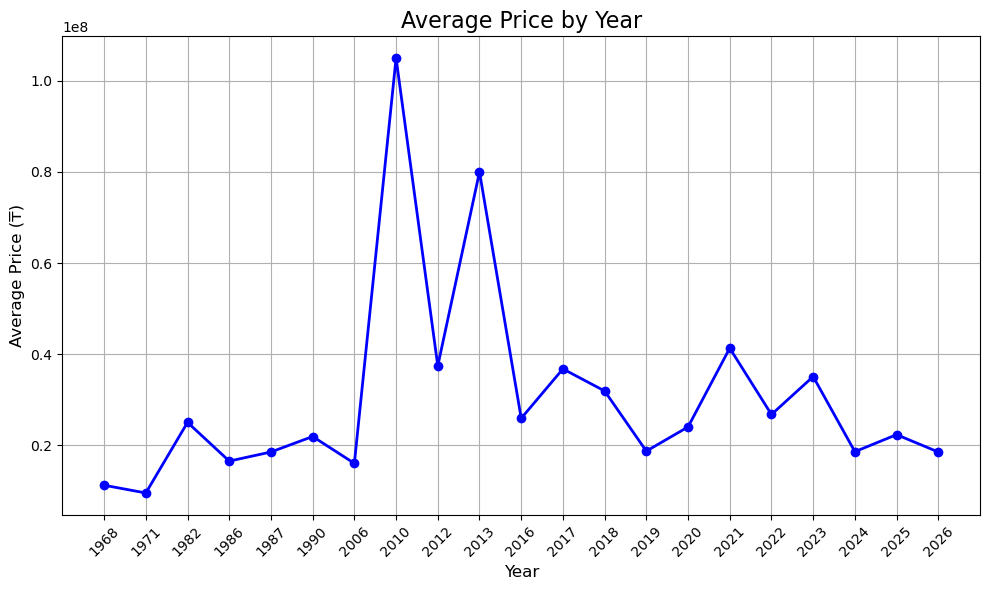

In [90]:
import matplotlib.pyplot as plt

# Group by 'Date' (Year) and calculate average price
average_price_by_year = df.groupby('Date')['Price'].mean().reset_index()

# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(average_price_by_year['Date'], average_price_by_year['Price'], marker='o', color='b', linestyle='-', linewidth=2, markersize=6)

# Add title and labels
plt.title('Average Price by Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Price (₸)', fontsize=12)

# Show the plot
plt.grid(True)
plt.xticks(average_price_by_year['Date'], rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Ensure everything fits without overlap
plt.show()

C:\Users\A1\AppData\Local\Temp\ipykernel_3264\477552618.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df[['Price', 'Date', 'live_square', 'flat_floor']].corr()


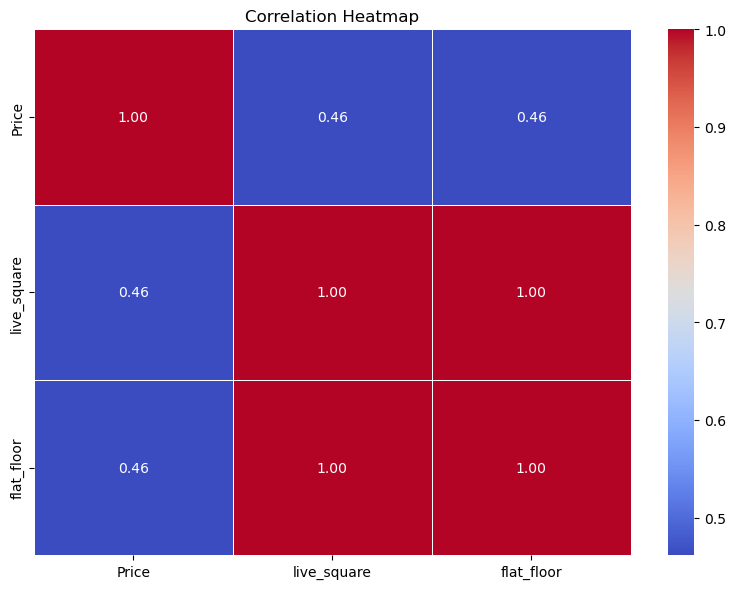

In [92]:
import seaborn as sns

# Calculate the correlation matrix for numerical columns
correlation_matrix = df[['Price', 'Date', 'live_square', 'flat_floor']].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Add title and show the plot
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

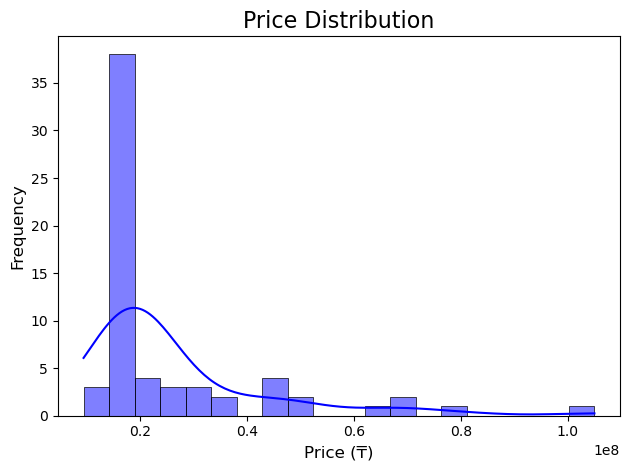

In [93]:
# Plot Histogram and KDE
sns.histplot(df['Price'], kde=True, bins=20, color='blue', edgecolor='black', linewidth=0.5)

# Add title and labels
plt.title('Price Distribution', fontsize=16)
plt.xlabel('Price (₸)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()

In [94]:
df

,Price,Date,Type_home,live_square,flat_floor
0,48000000,2020,монолитный,54.00,54.00
1,16000000,2006,кирпичный,68.00,68.00
2,45000000,2023,монолитный,91.00,91.00
3,65000000,2023,панельный,72.00,72.00
4,18000000,2022,кирпичный,58.30,58.30
...,...,...,...,...,...
59,18500000,2025,монолитный,70.93,70.93
60,18500000,2024,монолитный,58.10,58.10
61,18500000,2022,монолитный,83.14,83.14
62,18500000,2024,монолитный,130.18,130.18


In [99]:

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Apply LabelEncoder to the 'Type_home' column
df['Type_home'] = label_encoder.fit_transform(df['Type_home'])

df

,Price,Date,Type_home,live_square,flat_floor
0,48000000,2020,2,54.00,54.00
1,16000000,2006,1,68.00,68.00
2,45000000,2023,2,91.00,91.00
3,65000000,2023,3,72.00,72.00
4,18000000,2022,1,58.30,58.30
...,...,...,...,...,...
59,18500000,2025,2,70.93,70.93
60,18500000,2024,2,58.10,58.10
61,18500000,2022,2,83.14,83.14
62,18500000,2024,2,130.18,130.18


In [101]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Features and target variable
X = df[['Date', 'Type_home', 'live_square', 'flat_floor']]  # Features
y = df['Price']  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


y_train

13     16500000
34     18500000
50     18500000
3      65000000
17     14500000
49     18500000
8      18500000
6      50500000
33     18500000
4      18000000
47     18500000
19     30000000
54     18500000
41     18500000
55     31000000
31     47400000
30     46500000
59     18500000
60     18500000
15     25000000
27     26000000
26     22990000
24     20000000
46     18500000
11     18690000
32     43700000
57     18500000
45     18500000
37     18500000
29     12300000
43     18500000
48     18500000
1      16000000
21     17790000
2      45000000
62     18500000
39     18500000
35     18500000
23     11200000
53     18500000
10    105000000
22      9500000
18     18500000
63     18500000
20     21900000
7      37400000
42     68000000
14     20000000
28     80000000
51     18500000
38     18500000
Name: Price, dtype: int32

In [102]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict the target variable on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Output the results
print(f'Mean Squared Error: {mse}')
print(f'R² score: {r2}')

# Show some predicted vs actual prices
print("\nPredicted prices:", y_pred[:5])
print("Actual prices:", y_test.values[:5])

Mean Squared Error: 360882350404535.3
R² score: -0.6426239814820742

Predicted prices: [38631775.88653879 28975758.77477819 21337617.72012353 30814883.29811756
 36556208.97544182]
Actual prices: [18500000 18500000 48000000 18500000 69000000]
